## df_funder - Assisted Properties and Units by Funder: Cleaning & Exploration

The Affordable Housing Inventory (AHI) tracks **rental properties** that receive some form of government or quasi-government support. Each funder in this dataset provides assistance through grants, loans, or subsidies — directed either to the property developer/owner or directly to the renter. Importantly, not every unit within a funded property is necessarily assisted. A single property may be predominantly market-rate, with only a portion of its units receiving assistance (e.g., 70% market-rate, 30% assisted). This means that a funder's property count alone does not capture the depth of their support — the unit-level columns below are essential for understanding how much of each portfolio is actively assisted.

#### Column Descriptions

| Column | Description |
|--------|-------------|
| `Geography` | Geographic area the data applies to |
| `Funder` | Name of the funding source or agency |
| `Properties` | Number of assisted properties funded |
| `Total Units` | Total housing units across funded properties |
| `Assisted Units` | Units receiving rental or financial assistance |
| `HUD/RD Rental Assistance Units` | Units with HUD or USDA Rural Development rental assistance |
| `Public Housing ACC Units` | Units under a HUD Annual Contributions Contract |

**HUD** is the primary federal agency overseeing affordable housing programs, including rental assistance subsidies and Public Housing.

**USDA Rural Development** administers similar programs specifically for rural areas.

**Annual Contributions Contract** is a binding agreement between HUD and a Public Housing Authority that governs the funding and operation of public housing units.

> **NOTE:** Expand on specific programs offered by HUD and USDA RD and how they relate to the assistance types tracked in this dataset.

#### Funders

| Funder | Description |
|--------|-------------|
| Florida Housing Finance Corporation | State agency that finances affordable housing development through tax credits, loans, and other programs |
| HUD Multifamily | Federal programs that provide mortgage insurance and rental assistance for multifamily affordable housing |
| USDA Rural Development | Federal agency providing loans and grants for affordable housing in rural areas |
| Local Housing Finance Authority | Local or regional agencies that issue bonds and provide financing for affordable housing |
| HUD Public Housing | Federally funded public housing units owned and operated by local Public Housing Authorities |

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

df_funder = pd.read_csv("../Data/Cleaned Data/df_funder.csv")

funder_labels = {
    "A": "Florida Housing Finance Corporation",
    "B": "HUD Multifamily",
    "C": "USDA Rural Development",
    "D": "Local Housing Finance Authority",
    "E": "HUD Public Housing"
}
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]
codes = list(funder_labels.keys())
full_names = list(funder_labels.values())

df_funder.head()

,Geography,Funder,Properties,Total Units,Assisted Units,HUD/RD Rental Assistance Units,Public Housing ACC Units
0,Alachua County,Florida Housing Finance Corporation,36,3410,3136,762,171.0
1,Alachua County,HUD Multifamily,23,1631,1414,1116,NaN
2,Alachua County,USDA Rural Development,6,180,180,127,NaN
3,Alachua County,Local Housing Finance Authority,6,681,629,162,NaN
4,Alachua County,HUD Public Housing,5,871,753,0,823.0


### Preliminary Graphs

We use **bar charts** to graph four metrics across all five funders to get an initial sense of the distribution of assisted housing in Alachua County:

- **Properties** - number of assisted properties per funder
- **Total Units** - total housing units across funded properties
- **Assisted Units** - units actively receiving rental or financial assistance
- **HUD/RD Rental Assistance Units** - units specifically supported by HUD or USDA Rural Development rental assistance programs

Public Housing ACC Units are handled separately due to missing values across most funders - see the section below.

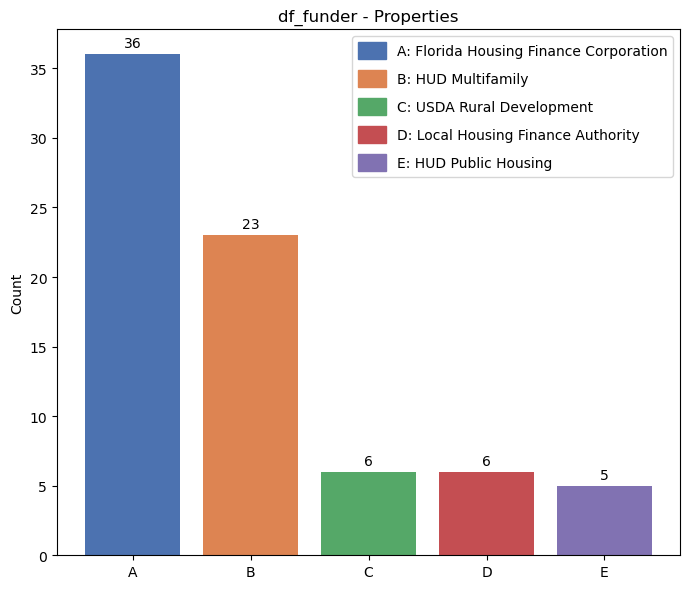

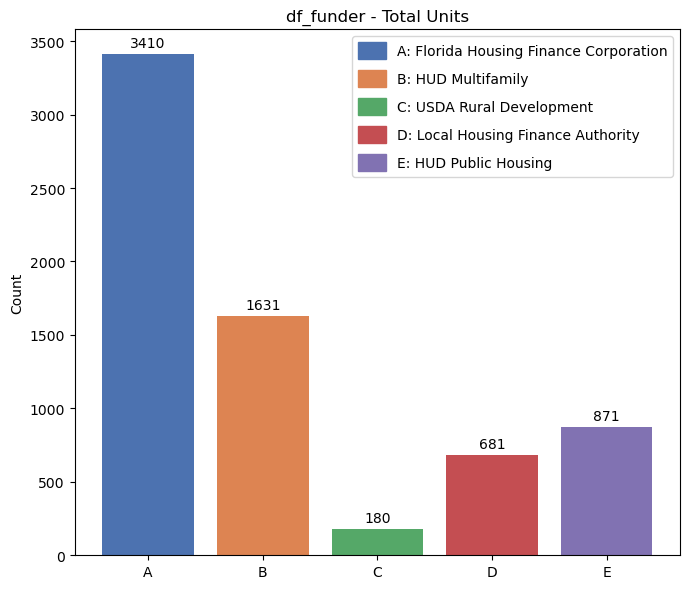

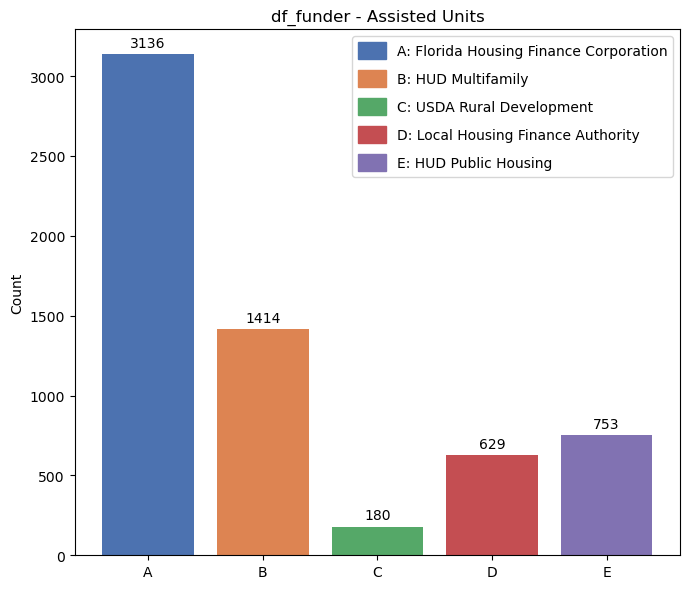

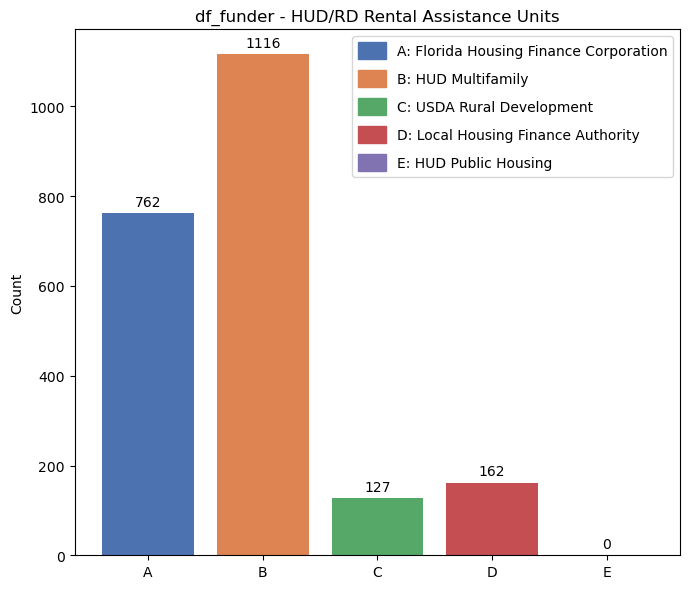

In [4]:
metrics = ["Properties", "Total Units", "Assisted Units", "HUD/RD Rental Assistance Units"]
filenames = [
    "df_funder_properties.png",
    "df_funder_total_units.png",
    "df_funder_assisted_units.png",
    "df_funder_hud_rd_rental_assistance_units.png"
]

legend_handles = [Patch(color=colors[i], label=f"{code}: {full_names[i]}") for i, code in enumerate(codes)]

for metric, filename in zip(metrics, filenames):
    values = df_funder.set_index("Funder").loc[full_names, metric].values

    fig, ax = plt.subplots(figsize=(7, 6))
    bars = ax.bar(codes, values, color=colors)
    ax.bar_label(bars, fmt="%g", fontsize=10, padding=3)
    ax.set_title(f"df_funder - {metric}")
    ax.set_ylabel("Count")
    ax.legend(handles=legend_handles, loc="upper right", fontsize=10, frameon=True, handlelength=2, handleheight=1.5, labelspacing=0.8)

    plt.tight_layout()
    plt.savefig(f"../Outputs/df_funder/{filename}", dpi=150, bbox_inches="tight")
    plt.show()

#### Observations

**Properties:**
- Florida Housing Finance Corporation funds by far the most properties at 36, with HUD Multifamily at second with 23. The other three fund about similar amounts - 6, 6, and 5 respectively.

**Total Units:**
- Similarly to the number of properties, Florida Housing Finance Corporation funds the most units at 3,410. HUD Multifamily is also at second with 1,631. Notably, USDA Rural Development is significantly lower at 180, probably because they fund rural areas, where units are less dense. This means although they sponsored the same number of properties as D and E, the number of units is significantly lower.

**Assisted Units:**
- The trend of assisted units follow total units very closely - 3,136; 1,414; 180; 629; 753.

**HUD/RD Rental Assistance Units:**
- HUD Multifamily fund the most rental assistance units at 1,116. Florida Housing Finance Corporation are at a close second with 762. HUD Public Housing have no units in this category.

**Overall takeaway:**
- We can see that Florida Housing Finance Corporation offer the largest and most widespread support for assisted living. We can also see that HUD Multifamily offer the most number of Rental Assistance. USDA RA and Local Authorities have significantly lower quantities and reach. 

### Public Housing ACC Units

Only two funders report Public Housing ACC Units: **HUD Public Housing** (823) and, notably, **Florida Housing Finance Corporation** (171). HUD Public Housing is expected here - ACC contracts are a core part of how HUD funds public housing. FHFC's presence is less straightforward. We plot these as a **bar chart** below.

The remaining three funders (HUD Multifamily, USDA Rural Development, Local Housing Finance Authority) have no ACC units - this is expected, as ACC contracts do not apply to their financing structures and are therefore excluded from the chart entirely rather than shown as zero.

> **NOTE:** Investigate why FHFC reports 171 ACC units. Likely explanation is layered financing - properties primarily financed through FHFC tax credits may also carry a HUD ACC contract. Worth confirming against the raw source data.

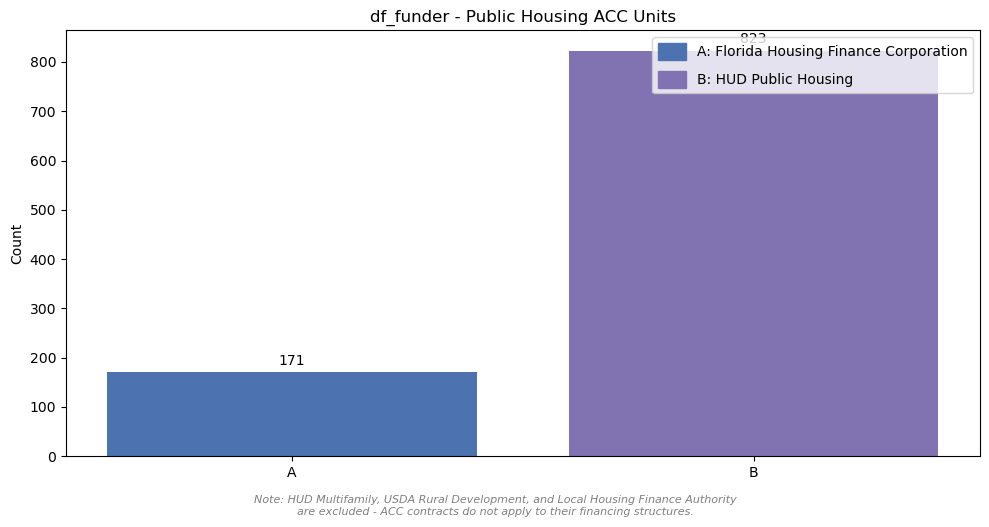

In [5]:
acc_data = df_funder[df_funder["Public Housing ACC Units"].notna()][["Funder", "Public Housing ACC Units"]]

acc_colors = {"Florida Housing Finance Corporation": "#4C72B0", "HUD Public Housing": "#8172B2"}
acc_funder_labels = {"A": "Florida Housing Finance Corporation", "B": "HUD Public Housing"}

acc_codes = list(acc_funder_labels.keys())
acc_names = list(acc_funder_labels.values())
values = acc_data.set_index("Funder").loc[acc_names, "Public Housing ACC Units"].values
bar_colors = [acc_colors[name] for name in acc_names]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(acc_codes, values, color=bar_colors)
ax.bar_label(bars, fmt="%g", fontsize=10, padding=3)
ax.set_title("df_funder - Public Housing ACC Units")
ax.set_ylabel("Count")

legend_handles = [Patch(color=bar_colors[i], label=f"{code}: {acc_names[i]}") for i, code in enumerate(acc_codes)]
ax.legend(handles=legend_handles, loc="upper right", fontsize=10, frameon=True, handlelength=2, handleheight=1.5, labelspacing=0.8)

fig.text(
    0.5, -0.04,
    "Note: HUD Multifamily, USDA Rural Development, and Local Housing Finance Authority\n"
    "are excluded - ACC contracts do not apply to their financing structures.",
    ha="center", fontsize=8, style="italic", color="gray"
)

plt.tight_layout()
plt.savefig("../Outputs/df_funder/df_funder_public_housing_acc_units.png", dpi=150, bbox_inches="tight")
plt.show()

#### Observations: Public Housing ACC Units

- **HUD Public Housing** dominates ACC units with 823 — nearly five times FHFC's 171. This is expected, as ACC contracts are the primary funding mechanism for public housing.
- **FHFC's 171 ACC units** are notable. Their presence likely reflects layered financing: properties primarily funded through FHFC tax credits or loans that also carry a HUD ACC contract. This means some properties appear in both funders' portfolios.
- The remaining three funders (HUD Multifamily, USDA Rural Development, Local Housing Finance Authority) report no ACC units, consistent with the fact that ACC contracts are specific to the public housing program and do not apply to their financing structures.

### Do Assisted Units Include HUD/RD Rental Assistance and Public Housing ACC Units?

We want to know whether `Assisted Units` already counts `HUD/RD Rental Assistance Units` and `Public Housing ACC Units` within it, or whether these are separate counts. If Assisted Units includes them, then adding HUD/RD + ACC together should never exceed Assisted Units. We test this below.

In [6]:
check = df_funder[["Funder", "Assisted Units", "HUD/RD Rental Assistance Units", "Public Housing ACC Units"]].copy()
check["sum_subcomponents"] = check["HUD/RD Rental Assistance Units"].fillna(0) + check["Public Housing ACC Units"].fillna(0)
check["sum_exceeds_assisted"] = check["sum_subcomponents"] > check["Assisted Units"]
check["hud_rd_exceeds_assisted"] = check["HUD/RD Rental Assistance Units"].fillna(0) > check["Assisted Units"]
check["acc_exceeds_assisted"] = check["Public Housing ACC Units"].fillna(0) > check["Assisted Units"]

check

,Funder,Assisted Units,HUD/RD Rental Assistance Units,Public Housing ACC Units,sum_subcomponents,sum_exceeds_assisted,hud_rd_exceeds_assisted,acc_exceeds_assisted
0,Florida Housing Finance Corporation,3136,762,171.0,933.0,False,False,False
1,HUD Multifamily,1414,1116,NaN,1116.0,False,False,False
2,USDA Rural Development,180,127,NaN,127.0,False,False,False
3,Local Housing Finance Authority,629,162,NaN,162.0,False,False,False
4,HUD Public Housing,753,0,823.0,823.0,True,False,True
5,"Total, All Funders",4338,1243,823.0,2066.0,False,False,False


For HUD Public Housing, ACC units (823) exceed Assisted Units (753). This means ACC units cannot be fully contained within Assisted Units - at least for this funder, they are counted separately. For all other funders, HUD/RD + ACC fits within Assisted Units, so the relationship is ambiguous.

For now, we treat them as **separate, non-overlapping counts** in any further analysis.

> **NOTE:** Revisit this assumption once we have more context on how the dataset was compiled.

### Assisted Units as a Proportion of Total Units

To understand how much of each funder's housing stock is actively assisted, we use an **overlaid bar chart**, plotting `Assisted Units` over `Total Units` for each funder. The total units bar serves as a frame, allowing us to visually assess what proportion of each funder's units are assisted.

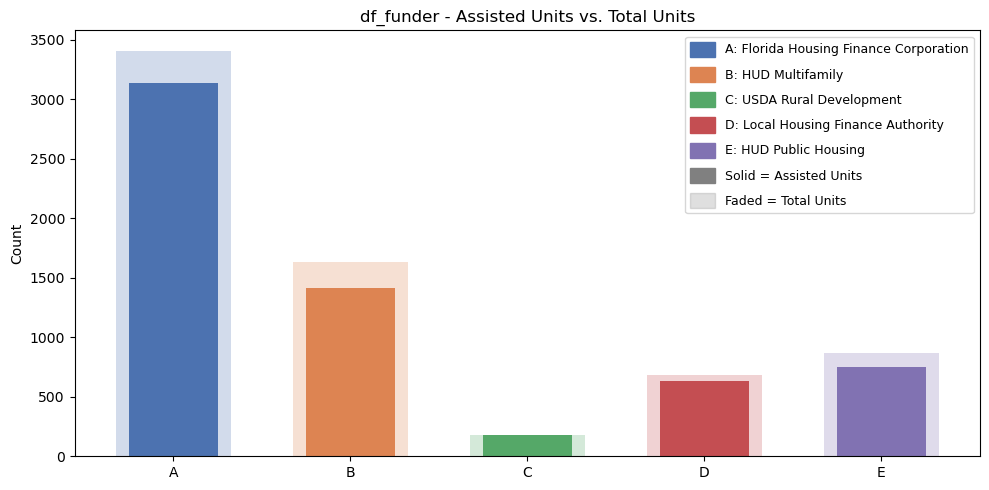

In [7]:
total = df_funder.set_index("Funder").loc[full_names, "Total Units"].values
assisted = df_funder.set_index("Funder").loc[full_names, "Assisted Units"].values

bar_width = 0.5

fig, ax = plt.subplots(figsize=(10, 5))

for i, (t, a, c) in enumerate(zip(total, assisted, colors)):
    ax.bar(i, t, width=bar_width + 0.15, color=c, alpha=0.25)
    ax.bar(i, a, width=bar_width, color=c, alpha=1.0)

ax.set_xticks(list(range(len(codes))))
ax.set_xticklabels(codes)
ax.set_title("df_funder - Assisted Units vs. Total Units")
ax.set_ylabel("Count")

legend_handles = [Patch(color=colors[i], label=f"{code}: {full_names[i]}") for i, code in enumerate(codes)]
legend_handles += [
    Patch(color="gray", alpha=1.0, label="Solid = Assisted Units"),
    Patch(color="gray", alpha=0.25, label="Faded = Total Units"),
]
ax.legend(handles=legend_handles, loc="upper right", fontsize=9, frameon=True, handlelength=2, handleheight=1.5, labelspacing=0.8)

plt.tight_layout()
plt.savefig("../Outputs/df_funder/df_funder_assisted_vs_total_units.png", dpi=150, bbox_inches="tight")
plt.show()

#### Observations: Assisted Units vs. Total Units

- **FHFC** has the largest absolute gap at 274 unassisted units, followed by **HUD Multifamily** at 217 and **HUD Public Housing** at 118.
- **Local Housing Finance Authority** has a small gap of 52, and **USDA Rural Development** has none - all 180 units are assisted.

### Unassisted Units Within Funded Properties

The gap between Total Units and Assisted Units represents units within a funder's portfolio that are not receiving active rental assistance. Possible explanations include:

- **Mixed-income properties** - FHFC's 274 unassisted units and HUD Multifamily's 217 likely reflect mixed-income developments where market-rate units count toward Total Units but are not assisted.
- **Funding without ongoing subsidy** - a funder may have provided a one-time loan or tax credit to build the property, but with no ongoing per-unit rental assistance attached. This could explain some of Local Housing Finance Authority's 52 unassisted units.
- **Expired assistance contracts** - units that previously had assistance that has since lapsed remain in the property count but no longer qualify as assisted. HUD Public Housing's 118 unassisted units may partially reflect this.
- **USDA Rural Development** is the only funder with no unassisted units, consistent with their model of directly subsidizing all units in smaller rural developments.

> **NOTE:** Confirm which funders have mixed-income properties and whether expired contracts are a meaningful factor in this dataset.

### Percent of Total Units That Are Assisted, by Funder

To compare the proportion of assisted units across funders on equal footing, we use a **100% stacked bar chart**. Each bar represents one funder's full portfolio, split into assisted and unassisted portions. This removes the distortion of different portfolio sizes and makes proportional comparisons direct.

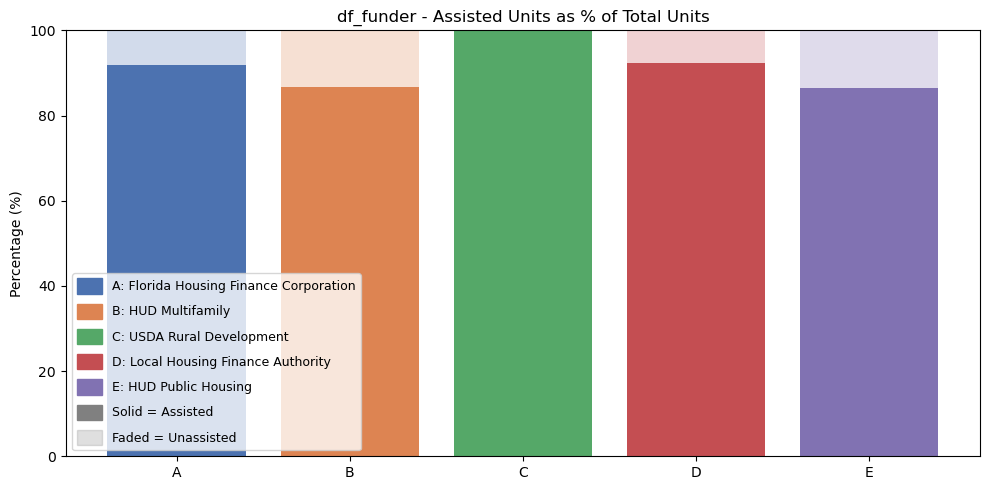

In [8]:
total = df_funder.set_index("Funder").loc[full_names, "Total Units"].values
assisted = df_funder.set_index("Funder").loc[full_names, "Assisted Units"].values

pct_assisted = assisted / total * 100
pct_unassisted = 100 - pct_assisted

fig, ax = plt.subplots(figsize=(10, 5))

for i, (pa, pu, c) in enumerate(zip(pct_assisted, pct_unassisted, colors)):
    ax.bar(i, pa, color=c, alpha=1.0)
    ax.bar(i, pu, bottom=pa, color=c, alpha=0.25)

ax.set_xticks(range(len(codes)))
ax.set_xticklabels(codes)
ax.set_title("df_funder - Assisted Units as % of Total Units")
ax.set_ylabel("Percentage (%)")
ax.set_ylim(0, 100)

legend_handles = [Patch(color=colors[i], label=f"{code}: {full_names[i]}") for i, code in enumerate(codes)]
legend_handles += [
    Patch(color="gray", alpha=1.0, label="Solid = Assisted"),
    Patch(color="gray", alpha=0.25, label="Faded = Unassisted"),
]
ax.legend(handles=legend_handles, loc="lower left", fontsize=9, frameon=True, handlelength=2, handleheight=1.5, labelspacing=0.8)

plt.tight_layout()
plt.savefig("../Outputs/df_funder/df_funder_pct_assisted.png", dpi=150, bbox_inches="tight")
plt.show()

#### Observations: Percent of Total Units Assisted

- **USDA Rural Development** is the only funder with a 100% assistance rate.
- **Local Housing Finance Authority** (92.4%) and **FHFC** (91.9%) are close behind, despite FHFC having the largest absolute gap.
- **HUD Multifamily** (86.7%) and **HUD Public Housing** (86.5%) have the lowest rates, nearly identical to each other.

### Total vs. Assisted Units per Property, by Funder

Normalizing by number of properties removes the effect of portfolio size and shows how intensive assistance is within an average property for each funder. We use the same **overlaid bar chart** approach, plotting Total Units per Property as a frame and Assisted Units per Property as the solid bar.

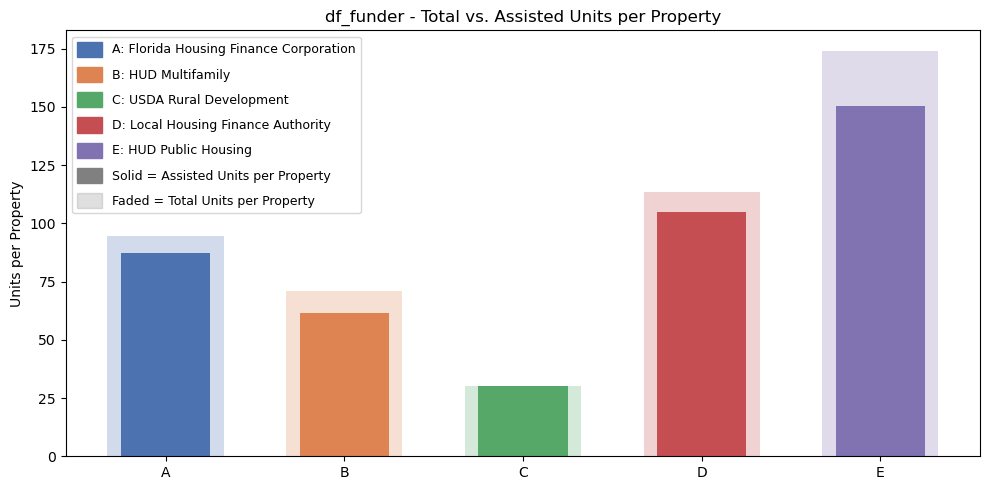

In [9]:
funder_data = df_funder.set_index("Funder").loc[full_names]
total_per_prop = funder_data["Total Units"] / funder_data["Properties"]
assisted_per_prop = funder_data["Assisted Units"] / funder_data["Properties"]

fig, ax = plt.subplots(figsize=(10, 5))

for i, (t, a, c) in enumerate(zip(total_per_prop, assisted_per_prop, colors)):
    ax.bar(i, t, width=0.65, color=c, alpha=0.25)
    ax.bar(i, a, width=0.5, color=c, alpha=1.0)

ax.set_xticks(range(len(codes)))
ax.set_xticklabels(codes)
ax.set_title("df_funder - Total vs. Assisted Units per Property")
ax.set_ylabel("Units per Property")

legend_handles = [Patch(color=colors[i], label=f"{code}: {full_names[i]}") for i, code in enumerate(codes)]
legend_handles += [
    Patch(color="gray", alpha=1.0, label="Solid = Assisted Units per Property"),
    Patch(color="gray", alpha=0.25, label="Faded = Total Units per Property"),
]
ax.legend(handles=legend_handles, loc="upper left", fontsize=9, frameon=True, handlelength=2, handleheight=1.5, labelspacing=0.8)

plt.tight_layout()
plt.savefig("../Outputs/df_funder/df_funder_units_per_property.png", dpi=150, bbox_inches="tight")
plt.show()

#### Observations: Total vs. Assisted Units per Property

- **HUD Public Housing** has the highest density at ~174 units/property, with a per-property gap of ~24 unassisted units.
- **USDA Rural Development** has the lowest density at ~30 units/property, expected given the rural context - smaller developments are the norm in less dense areas.
- **Local Housing Finance Authority** averages ~114 units/property, notably high for a local agency. **FHFC** sits at ~95 and **HUD Multifamily** at ~71.

### Percent of Units Assisted per Property, by Funder

Same **100% stacked bar chart** approach as the portfolio-level chart, but applied to per-property averages. This checks whether assistance rates hold when normalized by number of properties.

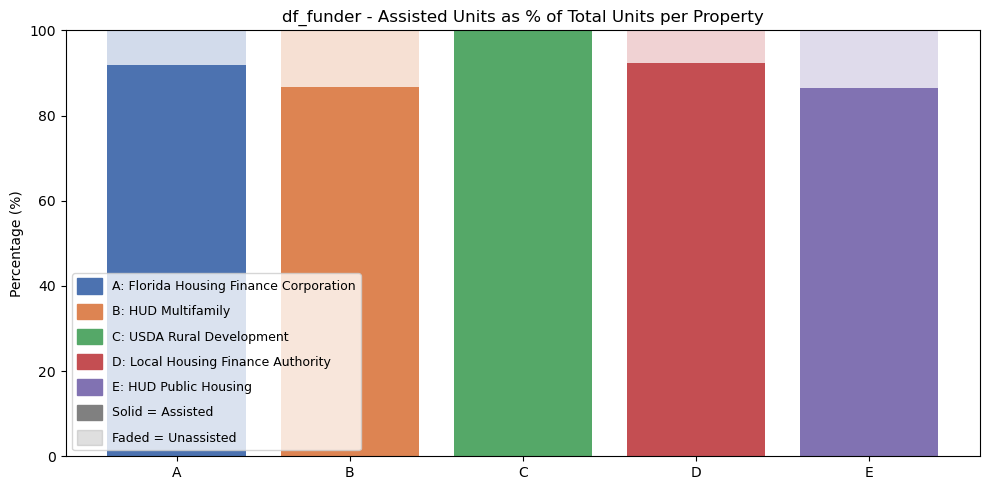

In [10]:
funder_data = df_funder.set_index("Funder").loc[full_names]
total_per_prop = funder_data["Total Units"] / funder_data["Properties"]
assisted_per_prop = funder_data["Assisted Units"] / funder_data["Properties"]

pct_assisted = assisted_per_prop / total_per_prop * 100
pct_unassisted = 100 - pct_assisted

fig, ax = plt.subplots(figsize=(10, 5))

for i, (pa, pu, c) in enumerate(zip(pct_assisted, pct_unassisted, colors)):
    ax.bar(i, pa, color=c, alpha=1.0)
    ax.bar(i, pu, bottom=pa, color=c, alpha=0.25)

ax.set_xticks(range(len(codes)))
ax.set_xticklabels(codes)
ax.set_title("df_funder - Assisted Units as % of Total Units per Property")
ax.set_ylabel("Percentage (%)")
ax.set_ylim(0, 100)

legend_handles = [Patch(color=colors[i], label=f"{code}: {full_names[i]}") for i, code in enumerate(codes)]
legend_handles += [
    Patch(color="gray", alpha=1.0, label="Solid = Assisted"),
    Patch(color="gray", alpha=0.25, label="Faded = Unassisted"),
]
ax.legend(handles=legend_handles, loc="lower left", fontsize=9, frameon=True, handlelength=2, handleheight=1.5, labelspacing=0.8)

plt.tight_layout()
plt.savefig("../Outputs/df_funder/df_funder_pct_assisted_per_property.png", dpi=150, bbox_inches="tight")
plt.show()

#### Observations: Percent of Units Assisted per Property

- The percentages here are identical to the portfolio-level % chart - dividing both assisted and total units by properties cancels out. This confirms the assistance rates (86-100%) are consistent across funders regardless of how many properties they manage.
- The per-property view's main value is in the absolute chart above, which reveals density differences invisible at the portfolio level.